# NYC Uber Trip Data - Exploratory Data Analysis

## Objective
Perform comprehensive exploratory analysis on NYC Uber yellow taxi trip data for January 2025
- Load and inspect data structure
- Analyze distributions and patterns
- Identify missing values and outliers
- Check data quality metrics
- Prepare insights for cleaning and transformation

### Dataset
- Source: NYC TLC Yellow Taxi Trip Records
- File: `yellow_tripdata_2025-01.parquet`
- Format: Apache Parquet
- Tools: pandas, numpy, matplotlib, seaborn, pyarrow

# Dataset Schema Documentation

| Column Name | Data Type | Description |
|---|---|---|
| VendorID | int32 | Identifier of the taxi vendor/company providing the trip service. |
| tpep_pickup_datetime | datetime64 | Timestamp when the trip started (pickup time). |
| tpep_dropoff_datetime | datetime64 | Timestamp when the trip ended (dropoff time). |
| passenger_count | float64 | Number of passengers in the trip. |
| trip_distance | float64 | Total trip distance in miles. |
| RatecodeID | float64 | Type of fare rate applied to the trip. |
| store_and_fwd_flag | object | Indicates whether the trip record was temporarily stored before being sent to the server (`Y` or `N`). |
| PULocationID | int32 | Pickup location zone identifier. |
| DOLocationID | int32 | Dropoff location zone identifier. |
| payment_type | int64 | Payment method used for the trip. |
| fare_amount | float64 | Base fare amount charged for the trip. |
| extra | float64 | Additional charges such as night or rush hour fees. |
| mta_tax | float64 | MTA (Metropolitan Transportation Authority) tax amount. |
| tip_amount | float64 | Tip amount paid by the passenger. |
| tolls_amount | float64 | Total toll charges during the trip. |
| improvement_surcharge | float64 | Extra surcharge added for transportation improvements. |
| total_amount | float64 | Final total amount paid by the passenger. |
| congestion_surcharge | float64 | Additional congestion fee applied in busy city areas. |
| Airport_fee | float64 | Additional airport-related fee. |
| cbd_congestion_fee | float64 | Central Business District congestion fee. |

---

# Notes

## Payment Type Reference

| Code | Payment Type |
|---|---|
| 1 | Credit Card |
| 2 | Cash |
| 3 | No Charge |
| 4 | Dispute |
| 5 | Unknown |
| 6 | Voided Trip |

---

# RateCodeID Reference

| Code | Description |
|---|---|
| 1 | Standard Rate |
| 2 | JFK |
| 3 | Newark |
| 4 | Nassau/Westchester |
| 5 | Negotiated Fare |
| 6 | Group Ride |

## Step 1: Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [2]:
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Data path

In [3]:
data_dir = Path('../../data')
sample_file = data_dir / 'yellow_tripdata_2025-01.parquet'

In [4]:
print(f"Loading data from: {sample_file}")
print(f"File exists: {sample_file.exists()}")

Loading data from: ..\..\data\yellow_tripdata_2025-01.parquet
File exists: True


# Load the data

In [5]:
df = pd.read_parquet(sample_file)
print(f"\nDataset: Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")


Dataset: Shape: (3475226, 20)
Rows: 3,475,226 | Columns: 20


# 1. Column Info

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [7]:
print("\nColumn Information:")
for col in df.columns:
    dtype = df[col].dtype
    non_null = df[col].notna().sum()
    non_null_pct = (non_null / len(df)) * 100
    null_count = df[col].isna().sum()
    null_pct = (null_count / len(df)) * 100
    print(
        f"{col:<30} | "
        f"Type: {str(dtype):<20} | "
        f"Non-Null: {non_null:>8} ({non_null_pct:>5.1f}%) | "
        f"Nulls: {null_count:>8} ({null_pct:>5.1f}%)"
    )


Column Information:
VendorID                       | Type: int32                | Non-Null:  3475226 (100.0%) | Nulls:        0 (  0.0%)
tpep_pickup_datetime           | Type: datetime64[us]       | Non-Null:  3475226 (100.0%) | Nulls:        0 (  0.0%)
tpep_dropoff_datetime          | Type: datetime64[us]       | Non-Null:  3475226 (100.0%) | Nulls:        0 (  0.0%)
passenger_count                | Type: float64              | Non-Null:  2935077 ( 84.5%) | Nulls:   540149 ( 15.5%)
trip_distance                  | Type: float64              | Non-Null:  3475226 (100.0%) | Nulls:        0 (  0.0%)
RatecodeID                     | Type: float64              | Non-Null:  2935077 ( 84.5%) | Nulls:   540149 ( 15.5%)
store_and_fwd_flag             | Type: object               | Non-Null:  2935077 ( 84.5%) | Nulls:   540149 ( 15.5%)
PULocationID                   | Type: int32                | Non-Null:  3475226 (100.0%) | Nulls:        0 (  0.0%)
DOLocationID                   | Type: int3

# 2. First few rows

In [8]:
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


# 3. Statistical Summary

In [9]:
print("\nNumerical Columns Summary:")
print("=" * 70)
df.describe().round(2)


Numerical Columns Summary:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,3475226.00,3475226,3475226,2935077.00,3475226.00,2935077.00,3475226.00,3475226.00,3475226.00,3475226.00,3475226.00,3475226.00,3475226.00,3475226.00,3475226.00,3475226.00,2935077.00,2935077.00,3475226.00
mean,1.79,2025-01-17 11:02:55.910964,2025-01-17 11:17:56.997901,1.30,5.86,2.48,165.19,164.13,1.04,17.08,1.32,0.48,2.96,0.45,0.95,25.61,2.23,0.12,0.48
min,1.00,2024-12-31 20:47:55,2024-12-18 07:52:40,0.00,0.00,1.00,1.00,1.00,0.00,-900.00,-7.50,-0.50,-86.00,-126.94,-1.00,-901.00,-2.50,-1.75,-0.75
25%,2.00,2025-01-10 07:59:01,2025-01-10 08:15:29.500000,1.00,0.98,1.00,132.00,113.00,1.00,8.60,0.00,0.50,0.00,0.00,1.00,15.20,2.50,0.00,0.00
50%,2.00,2025-01-17 15:41:33,2025-01-17 15:59:34,1.00,1.67,1.00,162.00,162.00,1.00,12.11,0.00,0.50,2.45,0.00,1.00,19.95,2.50,0.00,0.75
75%,2.00,2025-01-24 19:34:06,2025-01-24 19:48:31,1.00,3.10,1.00,234.00,234.00,1.00,19.50,2.50,0.50,3.93,0.00,1.00,27.78,2.50,0.00,0.75
max,7.00,2025-02-01 00:00:44,2025-02-01 23:44:11,9.00,276423.57,99.00,265.00,265.00,5.00,863372.12,15.00,10.50,400.00,170.94,1.00,863380.37,2.50,6.75,0.75
std,0.43,NaN,NaN,0.75,564.60,11.63,64.53,69.40,0.70,463.47,1.86,0.14,3.78,2.00,0.28,463.66,0.90,0.47,0.36


# 4. Missing Values Analysis

In [10]:
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
if len(missing_data) > 0:
    print("\nMissing Values:")
    print("=" * 70)
    print(missing_data.to_string(index=False))
else:
    print("\nNo missing values found!")



Missing Values:
              Column  Missing_Count  Missing_Percentage
     passenger_count         540149               15.54
          RatecodeID         540149               15.54
  store_and_fwd_flag         540149               15.54
congestion_surcharge         540149               15.54
         Airport_fee         540149               15.54


# 5. Numeric Columns Analysis

In [11]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nData Types:")
print(f"Numeric Columns ({len(numeric_cols)}): {numeric_cols[:5]}{'...' if len(numeric_cols) > 5 else ''}")
print(f"Categorical Columns ({len(categorical_cols)}): {categorical_cols}")



Data Types:
Numeric Columns (17): ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID']...
Categorical Columns (1): ['store_and_fwd_flag']


# 6. Box plots for detecting outliers

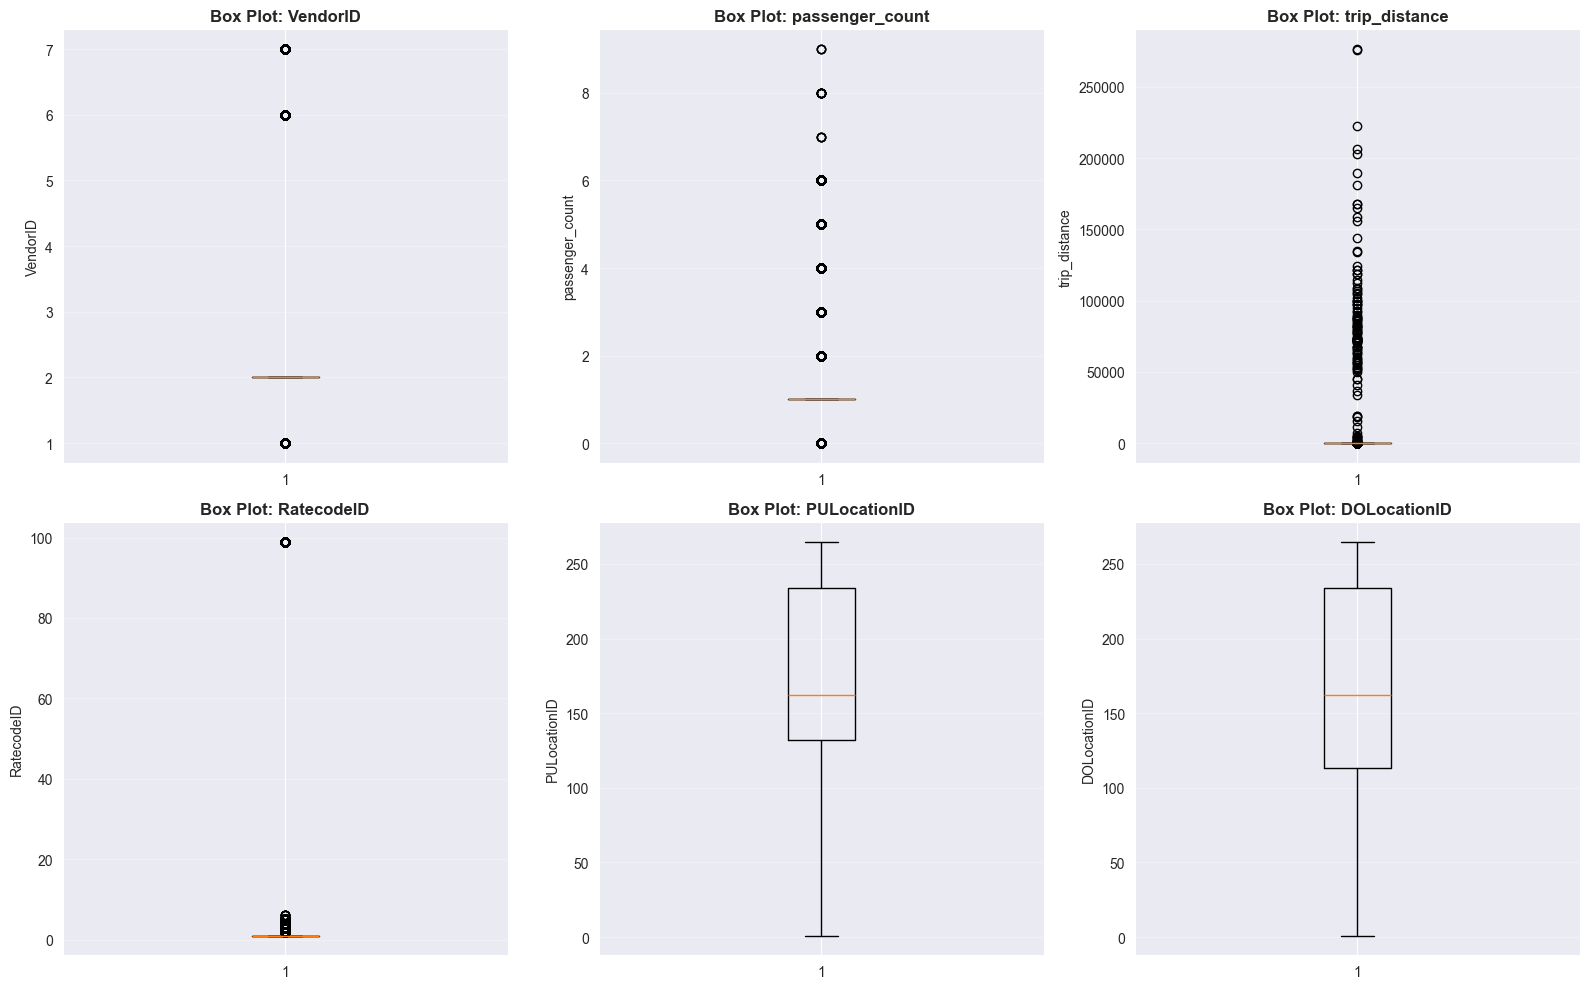


Box plots showing outliers


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols[:6]):
    axes[idx].boxplot(df[col].dropna(), vert=True)
    axes[idx].set_title(f'Box Plot: {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(col)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBox plots showing outliers")


# 7. Categorical Columns Analysis

In [13]:
print("\nCategorical Columns Value Counts:")
print("=" * 70)
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"Unique values: {df[col].nunique()}")
    print(f"Unique values: {df[col].unique()}")
    print(f"Top 5 values:")
    print(df[col].value_counts().head(5).to_string())



Categorical Columns Value Counts:

store_and_fwd_flag:
Unique values: 2
Unique values: ['N' 'Y' None]
Top 5 values:
store_and_fwd_flag
N    2927431
Y       7646


# 8. Correlation Matrix

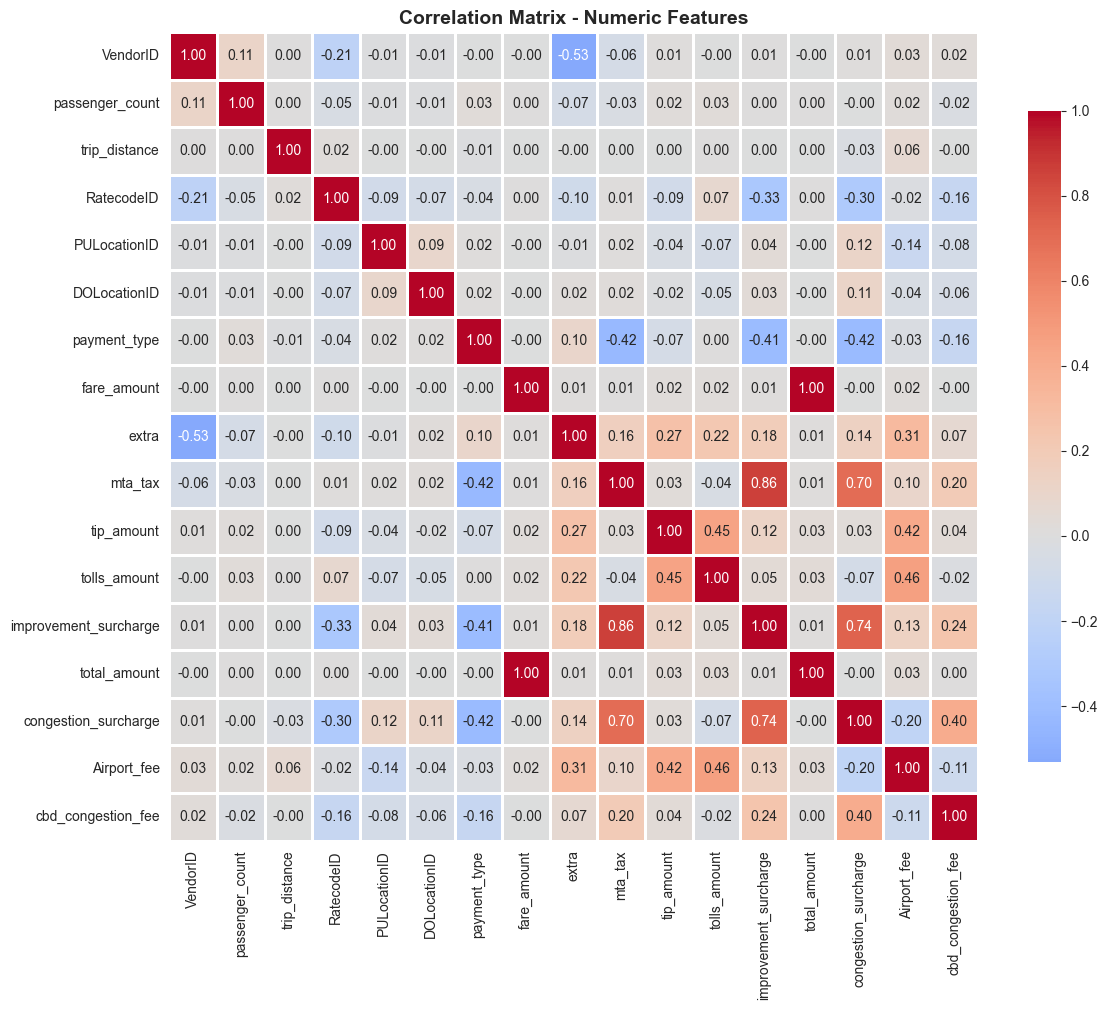


Correlation Matrix computed for 17 numeric columns


In [14]:
if len(numeric_cols) > 1:
    plt.figure(figsize=(12, 10))
    correlation_matrix = df[numeric_cols].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                fmt='.2f', square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix - Numeric Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f"\nCorrelation Matrix computed for {len(numeric_cols)} numeric columns")


# 9. Duplicate Rows Check

In [15]:
duplicate_count = df.duplicated().sum()
print(f"\nDuplicate Rows:")
print(f"Total duplicates: {duplicate_count}")
print(f"Duplicate percentage: {(duplicate_count/len(df)*100):.2f}%")
if duplicate_count > 0:
    print(f"\nFound {duplicate_count} duplicate rows - may need cleaning")
else:
    print(f"\nNo duplicate rows found")


Duplicate Rows:
Total duplicates: 0
Duplicate percentage: 0.00%

No duplicate rows found


# 10. Exploration Summary

In [16]:
print("\n" + "="*70)
print("EXPLORATION SUMMARY")
print("="*70)
print(f"Dataset Size: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Numeric Features: {len(numeric_cols)}")
print(f"Categorical Features: {len(categorical_cols)}")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicate Rows: {duplicate_count}")
print(f"Data Quality: {((df.notna().sum().sum() / (df.shape[0] * df.shape[1]) * 100)):.1f}%")
print("="*70)
print("\nExploration Complete! Ready for cleaning and transformation.")


EXPLORATION SUMMARY
Dataset Size: 3,475,226 rows × 20 columns
Memory Usage: 638.70 MB
Numeric Features: 17
Categorical Features: 1
Missing Values: 2700745
Duplicate Rows: 0
Data Quality: 96.1%

Exploration Complete! Ready for cleaning and transformation.


# Data Insights

## Dataset Overview

- Dataset contains taxi trip records for January 2025.
- Total rows: 3,475,226
- Data format: Parquet
- Main features include:
  - Pickup & Dropoff timestamps
  - Passenger count
  - Trip distance
  - Fare and total amount
  - Payment type
  - Pickup & Dropoff locations

---

# Data Quality Insights

## Missing Values

The following columns contain missing values:

| Column | Missing Percentage |
|---|---|
| passenger_count | 15.5% |
| RatecodeID | 15.5% |
| store_and_fwd_flag | 15.5% |
| congestion_surcharge | 15.5% |
| Airport_fee | 15.5% |

### Observations
- Most core trip columns are complete.
- Missing values mainly exist in optional or operational columns.
- `passenger_count` will be filled using default value = 1.
- `store_and_fwd_flag` missing values will be replaced with `"N"`.

---

# Data Type Insights

| Column Type | Examples |
|---|---|
| Integer | VendorID, PULocationID |
| Float | fare_amount, total_amount |
| Datetime | pickup/dropoff datetime |
| Object/String | store_and_fwd_flag |

### Observations
- Datetime columns are already parsed correctly.
- Numeric columns are suitable for aggregations and analytics.

---

# Trip Behavior Insights

## Time Analysis

The dataset contains:
- Pickup timestamps
- Dropoff timestamps

This enables:
- Peak hour analysis
- Traffic pattern analysis
- Average trip duration calculations

---

# Financial Insights

Available financial metrics:

- fare_amount
- tip_amount
- total_amount
- tolls_amount
- airport_fee

### Possible Analytics
- Revenue analysis
- Average fare trends
- Tip behavior analysis
- Airport trip revenue

---

# Geographic Insights

The dataset includes:
- Pickup Location ID
- Dropoff Location ID

This enables:
- Hotspot detection
- Most active areas
- Trip flow analysis
- Demand heatmaps

---

# Planned Transformations

## Cleaning Steps

- Remove duplicates
- Remove invalid trips
- Handle missing values
- Validate trip durations
- Validate fare and distance values

---

# Feature Engineering

New features to be created:

| Feature | Description |
|---|---|
| trip_duration_min | Trip duration in minutes |
| pickup_hour | Pickup hour |
| pickup_day | Pickup day |
| pickup_month | Pickup month |
| avg_speed | Average trip speed |

---

# Data Warehouse Design

## Fact Table

### Fact_Trips

Measures:
- Distance
- Fare
- Duration
- Total Amount

Keys:
- UserID
- DriverID
- PickupLocationID
- DropoffLocationID
- TimeID

---

# Dimension Tables

- Dim_Time
- Dim_Location
- Dim_Payment
- Dim_Driver
- Dim_User

# Full analysis report script  

In [18]:
from full_data_report import FullDataReport
data_dir = Path('../../data')
sample_file = data_dir / 'yellow_tripdata_2025-02.parquet'
FullDataReport.full_data_report(sample_file)

Loading data from: ..\..\data\yellow_tripdata_2025-02.parquet

Dataset: Shape: (3577543, 20)
Rows: 3,577,543 | Columns: 20

Column Information:
VendorID                       | Type: int32                | Non-Null:  3577543 (100.0%) | Nulls:        0 (  0.0%)
tpep_pickup_datetime           | Type: datetime64[us]       | Non-Null:  3577543 (100.0%) | Nulls:        0 (  0.0%)
tpep_dropoff_datetime          | Type: datetime64[us]       | Non-Null:  3577543 (100.0%) | Nulls:        0 (  0.0%)
passenger_count                | Type: float64              | Non-Null:  2770606 ( 77.4%) | Nulls:   806937 ( 22.6%)
trip_distance                  | Type: float64              | Non-Null:  3577543 (100.0%) | Nulls:        0 (  0.0%)
RatecodeID                     | Type: float64              | Non-Null:  2770606 ( 77.4%) | Nulls:   806937 ( 22.6%)
store_and_fwd_flag             | Type: object               | Non-Null:  2770606 ( 77.4%) | Nulls:   806937 ( 22.6%)
PULocationID                   | Type

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2025-02-01 00:12:18,2025-02-01 00:32:33,3.0,3.12,1.0,N,246,79,1,19.8,1.00,0.5,5.11,0.0,1.0,30.66,2.5,0.0,0.75
1,2,2025-02-01 00:40:04,2025-02-01 00:49:15,1.0,1.40,1.0,N,114,79,1,10.0,1.00,0.5,3.15,0.0,1.0,18.90,2.5,0.0,0.75
2,1,2025-02-01 00:06:09,2025-02-01 00:11:51,0.0,0.40,1.0,N,211,144,1,6.5,4.25,0.5,1.00,0.0,1.0,13.25,2.5,0.0,0.75
3,1,2025-02-01 00:15:13,2025-02-01 00:20:19,0.0,0.70,1.0,N,113,249,1,7.2,4.25,0.5,2.00,0.0,1.0,14.95,2.5,0.0,0.75
4,2,2025-02-01 00:02:52,2025-02-01 00:20:25,1.0,4.19,1.0,N,113,263,1,19.8,1.00,0.5,5.11,0.0,1.0,30.66,2.5,0.0,0.75



Numerical Columns Summary:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,3577543.00,3577543,3577543,2770606.00,3577543.00,2770606.00,3577543.00,3577543.00,3577543.00,3577543.00,3577543.00,3577543.00,3577543.00,3577543.00,3577543.00,3577543.00,2770606.00,2770606.00,3577543.00
mean,1.80,2025-02-15 03:32:25.140901,2025-02-15 03:47:49.613170,1.28,6.03,2.46,163.28,162.48,0.94,16.75,1.24,0.48,2.73,0.41,0.96,25.03,2.23,0.12,0.54
min,1.00,2025-01-31 22:22:53,2025-01-31 22:30:00,0.00,0.00,1.00,1.00,1.00,0.00,-1807.60,-7.50,-0.50,-220.00,-113.93,-1.00,-1832.85,-2.50,-1.75,-0.75
25%,2.00,2025-02-08 01:18:52,2025-02-08 01:31:19,1.00,1.00,1.00,125.00,113.00,1.00,8.60,0.00,0.50,0.00,0.00,1.00,15.31,2.50,0.00,0.00
50%,2.00,2025-02-14 21:06:49,2025-02-14 21:23:14,1.00,1.70,1.00,161.00,162.00,1.00,12.80,0.00,0.50,2.11,0.00,1.00,20.19,2.50,0.00,0.75
75%,2.00,2025-02-21 23:07:40.500000,2025-02-21 23:21:48.500000,1.00,3.18,1.00,233.00,234.00,1.00,19.80,2.50,0.50,3.79,0.00,1.00,27.97,2.50,0.00,0.75
max,7.00,2025-03-01 00:06:32,2025-03-01 23:13:42,9.00,228782.51,99.00,265.00,265.00,4.00,132531.36,22.55,10.50,440.00,115.87,1.00,132555.41,2.50,6.75,1.25
std,0.45,NaN,NaN,0.72,543.40,11.56,65.63,69.86,0.72,72.13,1.84,0.13,3.65,1.89,0.26,73.19,0.90,0.47,0.35



Missing Values:
              Column  Missing_Count  Missing_Percentage
     passenger_count         806937               22.56
          RatecodeID         806937               22.56
  store_and_fwd_flag         806937               22.56
congestion_surcharge         806937               22.56
         Airport_fee         806937               22.56

Data Types:
Numeric Columns (17): ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID']...
Categorical Columns (1): ['store_and_fwd_flag']

Categorical Columns Value Counts:

store_and_fwd_flag:
Unique values: 2
Unique values: ['N' 'Y' None]
Top 5 values:
store_and_fwd_flag
N    2742663
Y      27943

Duplicate Rows:
Total duplicates: 0
Duplicate percentage: 0.00%

No duplicate rows found

EXPLORATION SUMMARY
Dataset Size: 3,577,543 rows × 20 columns
Memory Usage: 649.37 MB
Numeric Features: 17
Categorical Features: 1
Missing Values: 4034685
Duplicate Rows: 0
Data Quality: 94.4%

Exploration Complete! Ready for cle

In [1]:
from pathlib import Path
import pandas as pd
from cleaning import clean_uber_data
from full_data_report import FullDataReport

def pipeline_run(data_path):
    print(f"Loading data: {data_path}")
    file_path = Path(data_path)
    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {data_path}")
    df = pd.read_parquet(file_path)

    print(f" Original shape: {df.shape}")
    df_clean = clean_uber_data(df)
    print(f"After cleaning: {df_clean.shape}")
    print("\nQuick Summary")
    print(df_clean.describe(include='number'))

    print("\nMissing Values")
    print(df_clean.isna().sum())
    FullDataReport.full_data_report(df_clean)
    return df_clean
data_dir = Path('../../data')
sample_file = data_dir / 'yellow_tripdata_2025-01.parquet'
pipeline_run(sample_file)

Loading data: ..\..\data\yellow_tripdata_2025-01.parquet
 Original shape: (3475226, 20)
After cleaning: (3252514, 21)

Quick Summary
           VendorID  passenger_count  trip_distance    RatecodeID  \
count  3.252514e+06     3.252514e+06   3.252514e+06  3.252514e+06   
mean   1.773634e+00     1.258300e+00   3.130460e+00  2.231555e+00   
std    4.211228e-01     7.068032e-01   3.926840e+00  1.066822e+01   
min    1.000000e+00     0.000000e+00   1.000000e-02  1.000000e+00   
25%    2.000000e+00     1.000000e+00   1.010000e+00  1.000000e+00   
50%    2.000000e+00     1.000000e+00   1.700000e+00  1.000000e+00   
75%    2.000000e+00     1.000000e+00   3.140000e+00  1.000000e+00   
max    6.000000e+00     9.000000e+00   1.958000e+01  9.900000e+01   

       PULocationID  DOLocationID  payment_type   fare_amount         extra  \
count  3.252514e+06  3.252514e+06  3.252514e+06  3.252514e+06  3.252514e+06   
mean   1.656632e+02  1.645992e+02  1.026326e+00  1.768777e+01  1.415942e+00   
std    6

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,...,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0,8.350000
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,...,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0,2.550000
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,...,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0,1.950000
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,...,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0,5.566667
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,...,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0,3.533333



Numerical Columns Summary:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration
count,3252514.00,3252514,3252514,3252514.00,3252514.00,3252514.00,3252514.00,3252514.00,3252514.00,3252514.00,3252514.00,3252514.00,3252514.00,3252514.00,3252514.00,3252514.00,3252514.00,3252514.00,3252514.00,3252514.00
mean,1.77,2025-01-17 09:41:22.029531,2025-01-17 09:56:30.175275,1.26,3.13,2.23,165.66,164.60,1.03,17.69,1.42,0.50,3.12,0.48,0.99,27.09,2.35,0.12,0.49,14.57
min,1.00,2024-12-31 20:47:55,2024-12-31 20:54:00,0.00,0.01,1.00,1.00,1.00,0.00,0.01,-3.25,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02
25%,2.00,2025-01-10 01:37:45.250000,2025-01-10 01:52:40.250000,1.00,1.01,1.00,132.00,114.00,1.00,8.60,0.00,0.50,0.00,0.00,1.00,15.94,2.50,0.00,0.00,7.33
50%,2.00,2025-01-17 14:03:23,2025-01-17 14:20:16.500000,1.00,1.70,1.00,162.00,162.00,1.00,12.80,1.00,0.50,2.59,0.00,1.00,20.35,2.50,0.00,0.75,11.70
75%,2.00,2025-01-24 19:18:32,2025-01-24 19:33:06,1.00,3.14,1.00,234.00,234.00,1.00,19.80,2.50,0.50,4.00,0.00,1.00,28.25,2.50,0.00,0.75,18.33
max,6.00,2025-02-01 00:00:44,2025-02-01 23:44:11,9.00,19.58,99.00,265.00,265.00,4.00,70.90,15.00,10.50,400.00,126.94,1.00,863380.37,2.50,1.75,0.75,59.33
std,0.42,NaN,NaN,0.71,3.93,10.67,64.26,69.31,0.59,14.67,1.86,0.05,3.76,2.01,0.11,479.16,0.60,0.43,0.36,10.69



No missing values found!

Data Types:
Numeric Columns (18): ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID']
Categorical Columns (1): ['store_and_fwd_flag']

Duplicate Rows:
Total duplicates: 0
Duplicate percentage: 0.00%

EXPLORATION SUMMARY
Dataset Size: 3,252,514 rows × 21 columns
Memory Usage: 663.79 MB
Numeric Features: 18
Categorical Features: 1
Missing Values: 0
Duplicate Rows: 0

Exploration Complete! Ready for cleaning and transformation.


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,...,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.00,8.350000
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,...,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.00,2.550000
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,...,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.00,1.950000
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,...,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.00,5.566667
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,...,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.00,3.533333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3475221,2,2025-01-31 23:01:48,2025-01-31 23:16:29,1.0,3.35,1.0,N,79,237,0,...,0.0,0.5,0.00,0.0,1.0,20.60,2.5,0.0,0.75,14.683333
3475222,2,2025-01-31 23:50:29,2025-02-01 00:17:27,1.0,8.73,1.0,N,161,116,0,...,0.0,0.5,0.00,0.0,1.0,32.89,2.5,0.0,0.75,26.966667
3475223,2,2025-01-31 23:26:59,2025-01-31 23:43:01,1.0,2.64,1.0,N,144,246,0,...,0.0,0.5,0.00,0.0,1.0,19.66,2.5,0.0,0.75,16.033333
3475224,2,2025-01-31 23:14:34,2025-01-31 23:34:52,1.0,3.16,1.0,N,142,107,0,...,0.0,0.5,0.00,0.0,1.0,22.30,2.5,0.0,0.75,20.300000


In [ ]:
# from sklearn.pipeline import Pipeline
# from pathlib import Path
# import pandas as pd
# from cleaning import clean_uber_data

# def load_data_step(data_path):
#     file_path = Path(data_path)
#     if not file_path.exists():
#         raise FileNotFoundError(f"File does not exist: {data_path}")
#     return pd.read_parquet(file_path)
# def cleaning_step(df):
#     return clean_uber_data(df)
# def report_step(df):
#     full_data_report(df)
#     return df
# def run_pipeline(data_path):
#     class DataLoader:
#         def fit(self, X, y=None): return self
#         def transform(self, X): return load_data_step(X)
#     class Cleaner:
#         def fit(self, X, y=None): return self
#         def transform(self, X): return cleaning_step(X)
#     class Reporter:
#         def fit(self, X, y=None): return self
#         def transform(self, X): report_step(X); return X
#     pipe = Pipeline([
#         ("load", DataLoader()),
#         ("clean", Cleaner()),
#         ("report", Reporter()),
#     ])
#     pipe.transform(data_path)

# data_dir = Path('../../data')
# sample_file = data_dir / 'yellow_tripdata_2025-02.parquet'
# run_pipeline(sample_file)